# Movie Reviews Sentiment Analysis

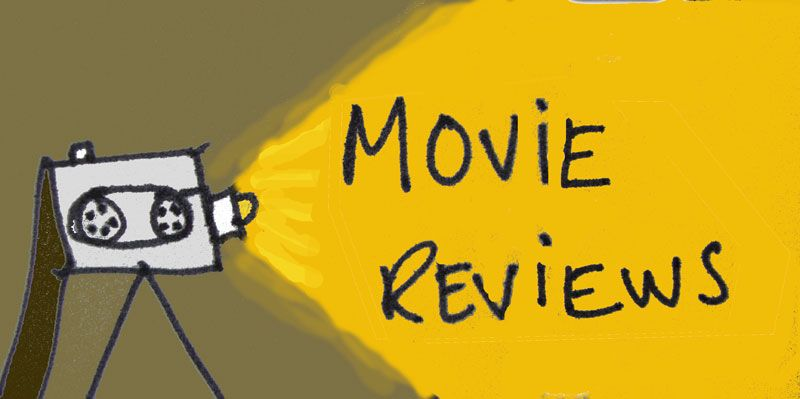
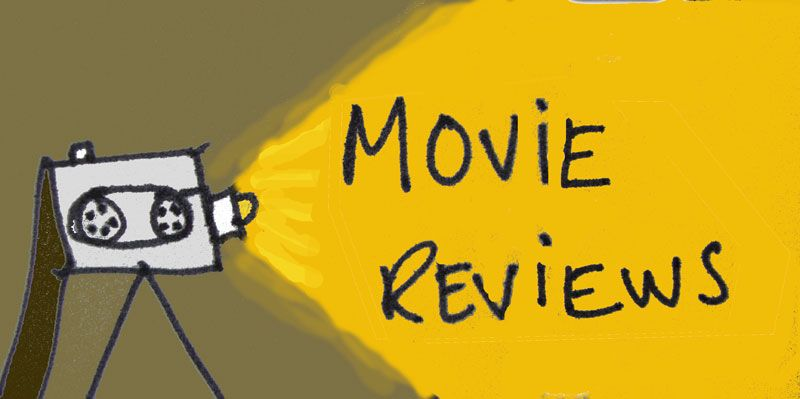

## Aim
The goal of this project is to leverage Word2Vec for sentiment analysis on movie reviews. By transforming words into meaningful vector representations, we aim to build a model that can accurately classify sentiments as positive or negative. This project will explore natural language processing (NLP) techniques, deep learning-based word embeddings, and sentiment classification.

## Introduction
Sentiment analysis, also known as opinion mining, is a crucial task in natural language processing (NLP) that involves determining the sentiment expressed in textual data. One of the major challenges in sentiment analysis is capturing the contextual meaning of words, especially when dealing with sarcasm, ambiguity, and complex sentence structures.

Word2Vec, developed by Google, is a deep learning-based method that represents words as dense vectors in a high-dimensional space. These vector representations capture semantic relationships between words, enabling machine learning models to understand text more effectively. Unlike traditional bag-of-words models, Word2Vec helps preserve word meaning and context, leading to improved sentiment classification performance.

This project will use an IMDB movie reviews dataset, which contains both positive and negative reviews. We will preprocess the text, train a Word2Vec model, and apply sentiment classification techniques to analyze the effectiveness of this approach.

## Dataset Columns Explanation
The dataset consists of the following columns:

- **id**: A unique identifier for each review.
- **sentiment**: The sentiment label for the review (1 for positive, 0 for negative).
- **review**: The actual text of the movie review, which can vary in length and complexity.

This dataset serves as the foundation for training and evaluating the sentiment analysis model using Word2Vec embeddings.

## Requirements

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',None)

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB 
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import nltk
nltk.download("stopwords")
import re
from nltk.corpus import stopwords
import string

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Import Data

In [3]:
df=pd.read_csv("/kaggle/input/word2vec-nlp-tutorial/labeledTrainData.tsv.zip",sep="\t")

## EDA (Exploratory Data Analysis)

In [4]:
df.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [6]:
df.isnull().sum()

id           0
sentiment    0
review       0
dtype: int64

In [7]:
df.shape

(25000, 3)

In [8]:
df["sentiment"].value_counts()

sentiment
1    12500
0    12500
Name: count, dtype: int64

## Preprocess Text

In [31]:
stemmer=nltk.SnowballStemmer("english")
stopword=set(stopwords.words("english"))
def clean_text(df,text_column):
    # Convert to lowercase
    df[text_column] = df[text_column].str.lower()
    
    # Remove unwanted characters
    df[text_column] = df[text_column].str.replace('[^\w\s]', '', regex=True)
    df[text_column] = df[text_column].str.replace('\w*\d\w*', '', regex=True)
    df[text_column] = df[text_column].str.replace('\n', '', regex=True)
    df[text_column] = df[text_column].str.replace('\r', '', regex=True)
    df[text_column] = df[text_column].str.replace('https?://\S+|www\.\S+', '', regex=True)
    df[text_column] = df[text_column].str.replace('<.*?>+', '', regex=True)
    df[text_column] = df[text_column].str.replace('\[.*?\]', '', regex=True)
    
    # Remove stopwords and apply stemming
    df[text_column] = df[text_column].apply(lambda x: ' '.join(
        stemmer.stem(word) 
        for word in x.split() 
        if word not in stopword
    ))
    return df[text_column]

In [10]:
df.iloc[0]["review"]

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

In [32]:
df["review"]=clean_text(df,"review")

In [12]:
df.iloc[0]["review"]

'stuff go moment mj ive start listen music watch odd documentari watch wiz watch moonwalk mayb want get certain insight guy thought realli cool eighti mayb make mind whether guilti innoc moonwalk part biographi part featur film rememb go see cinema origin releas subtl messag mjs feel toward press also obvious messag drug bad mkaybr br visual impress cours michael jackson unless remot like mj anyway go hate find bore may call mj egotist consent make movi mj fan would say made fan true realli nice himbr br actual featur film bit final start minut exclud smooth crimin sequenc joe pesci convinc psychopath power drug lord want mj dead bad beyond mj overheard plan nah joe pesci charact rant want peopl know suppli drug etc dunno mayb hate mjs musicbr br lot cool thing like mj turn car robot whole speed demon sequenc also director must patienc saint came film kiddi bad sequenc usual director hate work one kid let alon whole bunch perform complex danc scenebr br bottom line movi peopl like mj o

## Word Cloud

In [13]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS
from PIL import Image
def wc(data,color):
    plt.figure(figsize=(10,10))
   # mask=np.array(Image.open('cloud.png'))
    wc=WordCloud(background_color=color,stopwords=STOPWORDS)
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis('off')

## Word Cloud for Negative Texts

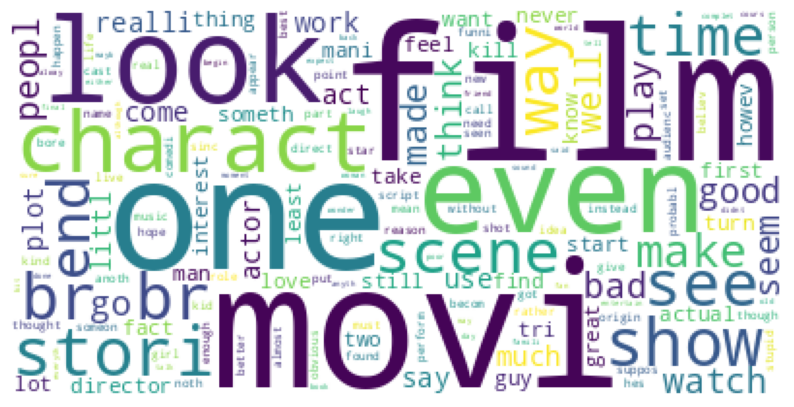

In [16]:
wc(df[df["sentiment"]==0]["review"],"white")

## Word Cloud for Positive Texts

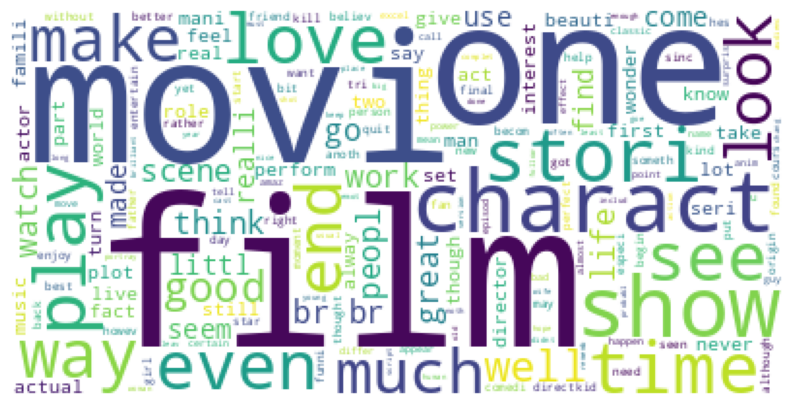

In [17]:
wc(df[df["sentiment"]==1]["review"],"white")

## The Most Used Words for Negative Texts

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(texts, ngram_range=(2, 3), top_n=10):
    vect = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    dtm = vect.fit_transform(texts)
    ngram_counts = dtm.sum(axis=0)
    ngrams_freq = [(word, ngram_counts[0, idx]) for word, idx in vect.vocabulary_.items()]
    return sorted(ngrams_freq, key=lambda x: x[1], reverse=True)[:top_n]

In [19]:
negative_text = df[df['sentiment'] == 1]['review']
negative_text_ngrams = get_top_ngrams(negative_text, ngram_range=(2, 2), top_n=20)
negative_text_ngrams

[('br br', 2964),
 ('br film', 878),
 ('ive seen', 759),
 ('br movi', 722),
 ('watch movi', 648),
 ('look like', 491),
 ('new york', 468),
 ('dont know', 457),
 ('movi like', 439),
 ('itbr br', 433),
 ('high recommend', 425),
 ('special effect', 420),
 ('year old', 404),
 ('year ago', 384),
 ('film like', 381),
 ('filmbr br', 377),
 ('good movi', 371),
 ('like movi', 367),
 ('main charact', 367),
 ('watch film', 365)]

## The Most Used Words for Positive Texts

In [20]:
positive_text = df[df['sentiment'] == 1]['review']
positive_text_ngrams = get_top_ngrams(positive_text, ngram_range=(2, 2), top_n=20)
positive_text_ngrams

[('br br', 2964),
 ('br film', 878),
 ('ive seen', 759),
 ('br movi', 722),
 ('watch movi', 648),
 ('look like', 491),
 ('new york', 468),
 ('dont know', 457),
 ('movi like', 439),
 ('itbr br', 433),
 ('high recommend', 425),
 ('special effect', 420),
 ('year old', 404),
 ('year ago', 384),
 ('film like', 381),
 ('filmbr br', 377),
 ('good movi', 371),
 ('like movi', 367),
 ('main charact', 367),
 ('watch film', 365)]

## Modelling

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB 
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier  
from sklearn.naive_bayes import MultinomialNB    


def classification_test(x,y,vect,confusion_mtr=False):
    b=BernoulliNB()
    l=LogisticRegression()
    d=DecisionTreeClassifier()
    rf=RandomForestClassifier()
    h=GradientBoostingClassifier()
    a=AdaBoostClassifier()
    m=MultinomialNB()
    algos=[b,l,d,rf,h,a,b]

    algo_names=['Bernoulli NB','Logistic Regression','Decision Tree Classifier','Random Forest Classifier','Gradient Boosting Classifier','Ada Boost Classifier','Multinomial NB']

    accuracy=[]
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

    result=pd.DataFrame(columns=['Accuracy Score'],index=algo_names)

    for i, algo in enumerate(algos):
        x_train_dtm = vect.fit_transform(x_train)
        x_test_dtm = vect.transform(x_test)

        if hasattr(algo, 'fit'):
            x_train_dtm = x_train_dtm  
            x_test_dtm = x_test_dtm   

        p = algo.fit(x_train_dtm, y_train).predict(x_test_dtm)
        accuracy.append(accuracy_score(y_test, p))
        if confusion_mtr:
            cm = confusion_matrix(y_test, p)
            plt.figure(figsize=(5, 5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=algo.classes_, yticklabels=algo.classes_,cbar=None)
            plt.title(f"Confusion Matrix - {algo_names[i]}")
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.show()

    result['Accuracy Score']=accuracy

    r_table=result.sort_values('Accuracy Score',ascending=False)
    
        
        
    return r_table[['Accuracy Score']]
    

In [22]:
x=df["review"]
y=df["sentiment"]

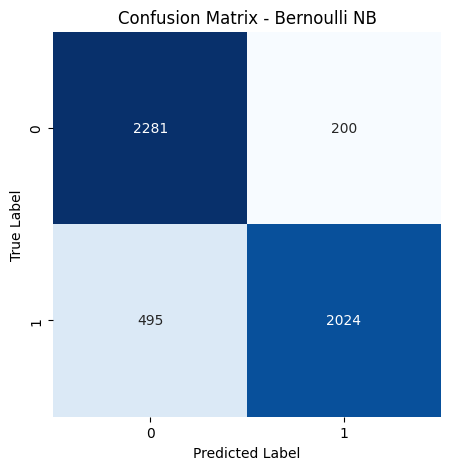

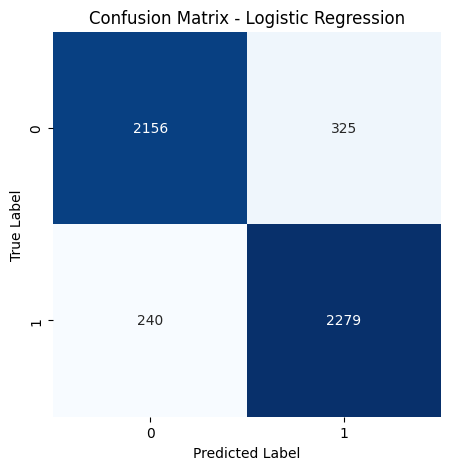

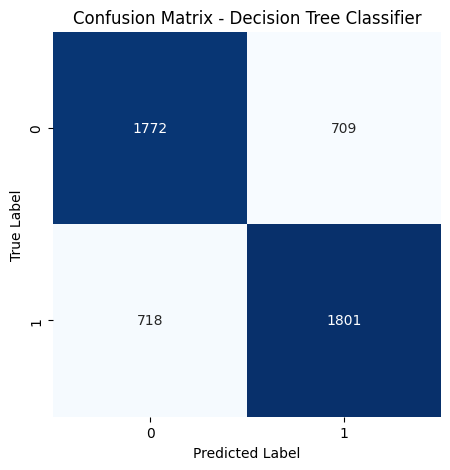

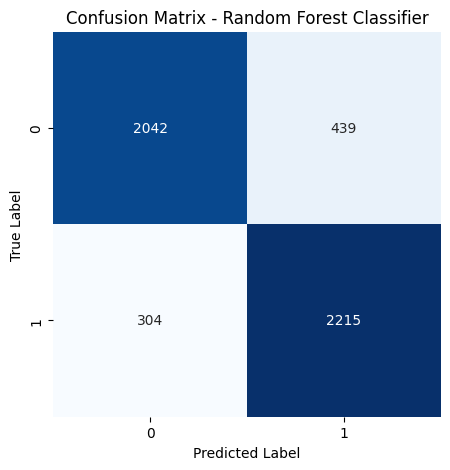

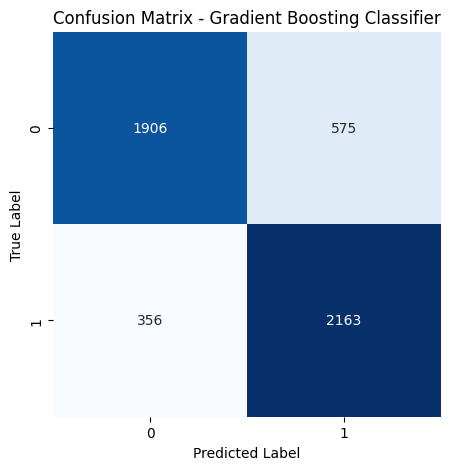

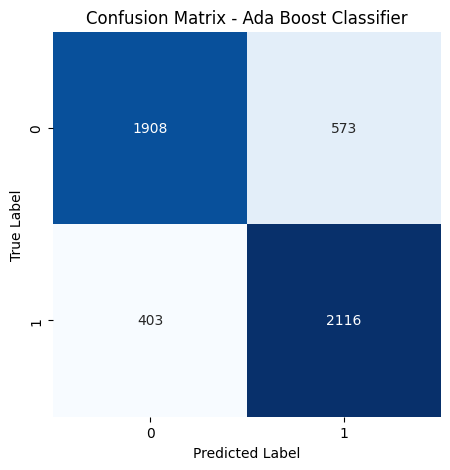

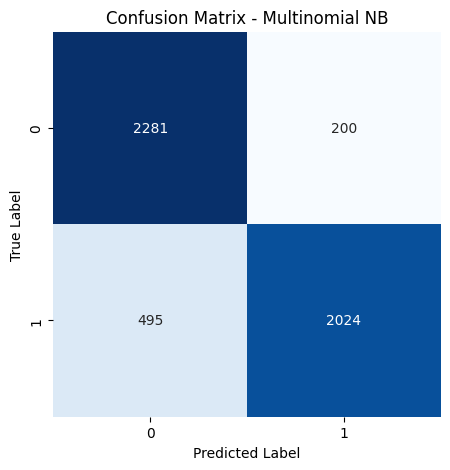

,Accuracy Score
Logistic Regression,0.8870
Bernoulli NB,0.8610
Multinomial NB,0.8610
Random Forest Classifier,0.8514
Gradient Boosting Classifier,0.8138
Ada Boost Classifier,0.8048
Decision Tree Classifier,0.7146


In [23]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer(ngram_range=(1,2))
classification_test(x,y,vect,confusion_mtr=True)

In [24]:
vect = CountVectorizer(ngram_range=(1,2))
l=LogisticRegression()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train_dtm = vect.fit_transform(x_train)
x_test_dtm = vect.transform(x_test)
model=l.fit(x_train_dtm, y_train)

In [25]:
import joblib  

joblib.dump(model, 'logistic_regression_model.pkl')
joblib.dump(vect, 'vectorizer.pkl')

['vectorizer.pkl']

## Testing the Model

In [26]:
df_test=pd.read_csv("/kaggle/input/word2vec-nlp-tutorial/testData.tsv.zip",sep="\t")

In [27]:
df_test.head()

,id,review
0,12311_10,Naturally in a film who's main themes are of m...
1,8348_2,This movie is a disaster within a disaster fil...
2,5828_4,"All in all, this is a movie for kids. We saw i..."
3,7186_2,Afraid of the Dark left me with the impression...
4,12128_7,A very accurate depiction of small time mob li...


In [33]:
df_test["review"]=clean_text(df_test,"review")

In [35]:
test_data= vect.transform(df_test["review"])
predictions=model.predict(test_data)

In [36]:
df_test["predictions"]=predictions

In [37]:
df_test.head()

,id,review,predictions
0,12311_10,natur film whos main theme mortal nostalgia lo...,1
1,8348_2,movi disast within disast film full great acti...,0
2,5828_4,movi kid saw tonight child love one point kid ...,1
3,7186_2,afraid dark left impress sever differ screenpl...,1
4,12128_7,accur depict small time mob life film new jers...,1


In [38]:
submission=pd.DataFrame({
    "id":df_test["id"],
    "sentiment":df_test["predictions"]
})

In [39]:
submission.to_csv("submission.csv",index=False)

## Conclusion
Based on our sentiment analysis results, Logistic Regression achieved the highest accuracy score of **88.70%**, outperforming other classifiers. The confusion matrix for Logistic Regression indicates strong performance, with relatively low misclassification rates.

Among the other models, **Bernoulli Naïve Bayes and Multinomial Naïve Bayes** performed similarly, both achieving **86.10% accuracy**, while **Random Forest Classifier** followed closely with **85.14% accuracy**. 

On the other hand, **Gradient Boosting Classifier (81.38%)** and **Ada Boost Classifier (80.48%)** exhibited lower performance compared to Logistic Regression. **Decision Tree Classifier** had the lowest accuracy at **71.46%**, indicating that tree-based methods might not be optimal for this specific task without further hyperparameter tuning.

Overall, the results suggest that traditional machine learning algorithms such as Logistic Regression and Naïve Bayes are well-suited for sentiment classification tasks when combined with appropriate text preprocessing and feature extraction techniques like Word2Vec.